######### 실습 데이터 생성 #################
X shape: (100, 2)
y shape: (100,)
First sample: [ 1.64565359 -0.5364869 ]
First label: 1

############ 데이터 시각화 #################


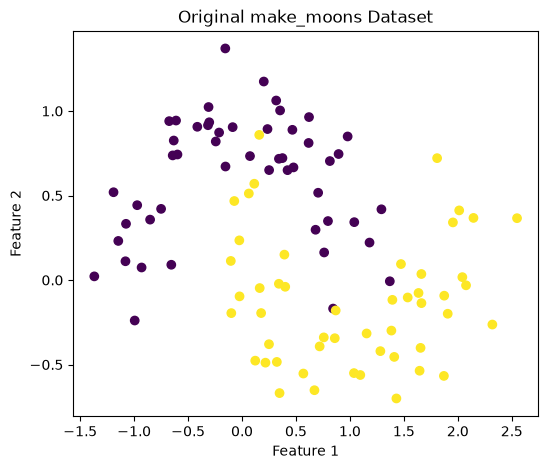


############ 데이터 스케일링 ###############
Before scaling
min: [-1.3688344  -0.70039729]
max: [2.54857762 1.36984215]

After scaling
min: [0. 0.]
max: [3.14159265 3.14159265]

########## Train / Test 분리 ###############
X_train: (80, 2)
X_test: (20, 2)
########## Feature Dimension 결정 ################
Feature Dimension: 2

####### 기본 ZZFeatureMap 생성 ========
   ┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘
   ┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘

Feat

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from qiskit.circuit.library import zz_feature_map

######### 실습 데이터 생성 #################
print("######### 실습 데이터 생성 #################")
# make_moons 데이터 생성
X, y = make_moons(
    n_samples=100,
    noise=0.2,
    random_state=42
)

# 데이터 구조 확인
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First sample:", X[0])
print("First label:", y[0])
print()

############# 데이터 시각화 #################
print("############ 데이터 시각화 #################")
# 원본 데이터 분포 확인
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original make_moons Dataset")
plt.show()

print()
############ 데이터 스케일링 ###############
print("############ 데이터 스케일링 ###############")

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

print("Before scaling")
print("min:", X.min(axis=0))
print("max:", X.max(axis=0))

print("\nAfter scaling")
print("min:", X_scaled.min(axis=0))
print("max:", X_scaled.max(axis=0))

print()
########## Train / Test 분리 ###############

print("########## Train / Test 분리 ###############")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

########## Feature Dimension 결정 ################
print("########## Feature Dimension 결정 ################")

feature_dimension = X_train.shape[1]
print("Feature Dimension:", feature_dimension)



print()

######## 기본 ZZFeatureMap 생성 ========

print("####### 기본 ZZFeatureMap 생성 ========")
feature_map = zz_feature_map(
    feature_dimension=2,
    reps=1,
    entanglement="linear"
)
print(feature_map)


############### 회로 시각화 ###############
feature_map.draw("mpl")
plt.show()

print(feature_map.draw("text"))

print()


########## 회로 파라미터 확인 ###########
print("Feature Map Parameters")
print("----------------------")

for param in feature_map.parameters:
    print(param)

############ 실제 데이터 바인딩 ##########

print("############ 실제 데이터 바인딩 ##########")

sample = X_train[0]
print("Sample:", sample)

param_dict = {
    param: value
    for param, value in zip(feature_map.parameters, sample)
}

bound_circuit = feature_map.assign_parameters(param_dict)

print(bound_circuit.draw("text"))

########## Binding된 회로 출력 #############
print("="*60)
print("STEP 10. Bound Circuit")
print("="*60)

bound_circuit.draw("mpl")

plt.show()

############## reps 비교 ##############

print("="*60)
print("STEP 11. Compare reps")
print("="*60)

for reps in [1,2,3]:

    fm = zz_feature_map(
        feature_dimension=2,
        reps=reps
    )

    print(f"reps={reps}")

    print("Depth :", fm.depth())

    print("Operations")

    print(fm.count_ops())

    print("-"*50)

############## Entanglement 비교 ##############

print("="*60)
print("STEP 12. Compare Entanglement")
print("="*60)

for ent in ["linear","full","circular"]:

    fm = zz_feature_map(
        feature_dimension=4,
        reps=1,
        entanglement=ent
    )

    print(ent)

    print("Depth :", fm.depth())

    print("Operations")

    print(fm.count_ops())

    print("-"*50)

############# 회로 복잡도 계산 ###############

print("="*60)
print("STEP 13. Circuit Analysis")
print("="*60)

print("Number of Qubits")

print(feature_map.num_qubits)

print()

print("Number of Parameters")

print(len(feature_map.parameters))

print()

print("Circuit Depth")

print(feature_map.depth())

print()

print("Gate Count")

print(feature_map.count_ops())

################ Quantum Kernel 연결 ############

print("="*60)
print("STEP 14. Quantum Kernel")
print("="*60)

from qiskit_machine_learning.kernels import FidelityQuantumKernel

kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

print(kernel)








